In [1]:
# final_optimized_qc.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)
# from qiskit.visualization import plot_histogram, plot_distribution
# plot_distribution(final_counts, title= r'Bell State Distribution $Ry(3\pi/4)$', figsize=(5, 4), bar_labels=True)

In [ ]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import Initialize
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram # For plotting histograms
from scipy.special import rel_entr # For KL divergence calculation
from scipy.optimize import minimize # For angle optimization
import matplotlib.pyplot as plt # For plotting histograms
import itertools
import time # For timing measurements


def create_initial_circuit(state_vec_probs):
    """
    Creates a quantum circuit initialized to a given state vector.
    Args:
        state_vec_probs (list or np.array): The amplitudes of the state vector.
                                            Must be normalized and have a length of 2^num_qubits.
    Returns:
        QuantumCircuit: The circuit initialized to the specified state.
    """
    num_qubits = int(np.log2(len(state_vec_probs)))
    if not np.isclose(2**num_qubits, len(state_vec_probs)):
        raise ValueError("Length of state_vec_probs must be a power of 2.")

    qr = QuantumRegister(num_qubits, name='q')
    circuit = QuantumCircuit(qr)
    initial_state_instruction = Initialize(state_vec_probs)
    circuit.append(initial_state_instruction, qr)
    return circuit

def concatenate_circuits_with_separate_measurements(circ1: QuantumCircuit, circ2: QuantumCircuit) -> QuantumCircuit:
    """
    Concatenates two QuantumCircuit objects onto disjoint sets of qubits
    within a larger circuit and adds separate classical registers for measurement
    of each original circuit's qubits.

    Args:
        circ1 (QuantumCircuit): The first quantum circuit.
        circ2 (QuantumCircuit): The second quantum circuit.

    Returns:
        QuantumCircuit: A new circuit combining circ1 and circ2 on separate
                        qubits, with two distinct classical registers for measurements.
    """
    ng_circ1 = circ1.num_qubits
    ng_circ2 = circ2.num_qubits
    num_total_qubits = ng_circ1 + ng_circ2

    qr_all = QuantumRegister(num_total_qubits, name='q')
    cr_measure1 = ClassicalRegister(ng_circ1, name='c_measure1')
    cr_measure2 = ClassicalRegister(ng_circ2, name='c_measure2')

    circ_all = QuantumCircuit(qr_all, cr_measure1, cr_measure2)

    # Compose circ1 onto the first set of qubits
    circ_all.compose(circ1, qubits=range(ng_circ1), inplace=True)

    # Compose circ2 onto the next set of qubits
    circ_all.compose(circ2, qubits=range(ng_circ1, num_total_qubits), inplace=True)

    return circ_all

def add_cnots_and_measurements_to_circuit(
    base_circuit: QuantumCircuit,
    circ1_num_qubits: int,
    global_cnot_configurations: list[tuple[int, int]]
) -> QuantumCircuit:
    """
    Applies a specified list of CNOT gates (using global qubit indices)
    and then adds measurements to the circuit.

    Args:
        base_circuit (QuantumCircuit): The circuit already containing the two
                                        chunks composed on disjoint qubits.
                                        This circuit should NOT have measurements yet.
        circ1_num_qubits (int): The number of qubits in the first chunk.
                                This is used to determine the classical register split.
        global_cnot_configurations (list[tuple[int, int]]): A list of tuples, where each tuple
                                                      (global_control_idx, global_target_idx)
                                                      specifies a CNOT gate using global qubit indices.

    Returns:
        QuantumCircuit: A new circuit with the specified CNOTs and measurements added.
    """
    circuit_with_cnots = base_circuit.copy()

    qr_all = circuit_with_cnots.qregs[0]
    cr_measure1 = circuit_with_cnots.cregs[0]
    cr_measure2 = circuit_with_cnots.cregs[1]

    for control_q, target_q in global_cnot_configurations:
        # Add checks to ensure indices are valid within the combined circuit
        if not (0 <= control_q < circuit_with_cnots.num_qubits and
                0 <= target_q < circuit_with_cnots.num_qubits and
                control_q != target_q):
            raise ValueError(f"Invalid CNOT indices: ({control_q}, {target_q}). Qubits must be valid and distinct.")

        circuit_with_cnots.cx(qr_all[control_q], qr_all[target_q])

    # Add measurements after all CNOTs are applied
    circuit_with_cnots.measure(qr_all[0:circ1_num_qubits], cr_measure1)
    circuit_with_cnots.measure(qr_all[circ1_num_qubits:circuit_with_cnots.num_qubits], cr_measure2)

    return circuit_with_cnots


def add_crx_gates_and_measurements_to_circuit(
    base_circuit: QuantumCircuit,
    circ1_num_qubits: int,
    crx_configurations: list[tuple[int, int]], # List of (control, target) global indices
    angles: list[float] # List of angles corresponding to each CRX
) -> QuantumCircuit:
    """
    Applies a specified list of CRX gates (controlled-RX) with given angles
    and then adds measurements to the circuit.

    Args:
        base_circuit (QuantumCircuit): The circuit already containing the two
                                        chunks composed on disjoint qubits.
                                        This circuit should NOT have measurements yet.
        circ1_num_qubits (int): The number of qubits in the first chunk.
                                This is used to determine the classical register split.
        crx_configurations (list[tuple[int, int]]): A list of (control_q, target_q) global qubit
                                                     indices defining where CRX gates will be placed.
        angles (list[float]): A list of rotation angles for each CRX gate,
                              corresponding to the order in `crx_configurations`.

    Returns:
        QuantumCircuit: A new circuit with the specified CRX gates and measurements added.
    """
    circuit_with_crx = base_circuit.copy()
    qr_all = circuit_with_crx.qregs[0]
    cr_measure1 = circuit_with_crx.cregs[0]
    cr_measure2 = circuit_with_crx.cregs[1]

    if len(crx_configurations) != len(angles):
        raise ValueError("Number of CRX configurations must match the number of angles.")

    for i, (control_q, target_q) in enumerate(crx_configurations):
        # Add checks for valid indices
        if not (0 <= control_q < circuit_with_crx.num_qubits and
                0 <= target_q < circuit_with_crx.num_qubits and
                control_q != target_q):
            raise ValueError(f"Invalid CRX indices: ({control_q}, {target_q}). Qubits must be valid and distinct.")
        
        #circuit_with_crx.append(CRXGate(angles[i]), [qr_all[control_q], qr_all[target_q]])
        circuit_with_crx.crx(angles[i], qr_all[control_q], qr_all[target_q]) 

    # Add measurements after all CRX gates are applied
    circuit_with_crx.measure(qr_all[0:circ1_num_qubits], cr_measure1)
    circuit_with_crx.measure(qr_all[circ1_num_qubits:circuit_with_crx.num_qubits], cr_measure2)

    return circuit_with_crx

def get_probability_distribution(counts: dict, num_bits: int, total_shots: int) -> dict:
    """
    Converts a counts dictionary (e.g., {'00': 500, '11': 500}) into
    a probability distribution (e.g., {'00': 0.5, '11': 0.5}).
    Ensures all 2^num_bits outcomes are represented, even if count is 0.
    """
    prob_dist = {}
    for i in range(2**num_bits):
        bitstring = bin(i)[2:].zfill(num_bits)
        prob_dist[bitstring] = counts.get(bitstring, 0) / total_shots
    return prob_dist

def calculate_kl_divergence(p_dist: dict, q_dist: dict, epsilon=1e-9) -> float:
    """
    Calculates the Kullback-Leibler divergence D_KL(P || Q).
    P is the observed distribution, Q is the target distribution.
    Args:
        p_dist (dict): Observed probability distribution (e.g., from simulation).
        q_dist (dict): Target probability distribution.
        epsilon (float): A small value used to handle zero probabilities,
                         to avoid log(0) and division by zero.
    Returns:
        float: The KL divergence.
    """
    kl_div = 0.0

    # Get all possible outcomes from the union of keys to ensure comprehensive check.
    all_keys = sorted(list(set(p_dist.keys()).union(set(q_dist.keys()))))

    for key in all_keys:
        p_val = p_dist.get(key, 0.0) # Observed probability for this outcome
        q_val = q_dist.get(key, 0.0) # Target probability for this outcome

        if p_val > 0: # Only sum if the observed probability is non-zero
            if q_val == 0:
                kl_div += p_val * np.log(p_val / epsilon)
            else:
                kl_div += p_val * np.log(p_val / q_val)

    return kl_div

def score_circuit_kl_divergences(
    circuit_to_evaluate: QuantumCircuit,
    state_vec_probs_target1: list or np.ndarray,
    state_vec_probs_target2: list or np.ndarray,
    nshots: int = 1000
):
    """
    Evaluates a Qiskit circuit by simulating it and calculates KL divergences
    against provided target probability distributions derived from specific
    state vectors.

    Args:
        circuit_to_evaluate (QuantumCircuit): The Qiskit QuantumCircuit to simulate.
                                              This circuit should already have the
                                              desired CNOT configurations and measurements
                                              applied, and classical registers named
                                              'c_measure1' and 'c_measure2'.
        state_vec_probs_target1 (list or np.array): The amplitudes of the target state vector
                                                     for the first classical register (c_measure1).
        state_vec_probs_target2 (list or np.array): The amplitudes of the target state vector
                                                     for the second classical register (c_measure2).
        nshots (int): The number of shots for the simulation. Defaults to 1000.

    Returns:
        tuple: A tuple containing (kl_div1, kl_div2), which are the KL divergence
               values for c_measure1 and c_measure2 respectively.
               Returns (None, None) if an error occurs during simulation or result retrieval.
    """
    # Determine number of qubits for target distributions from the length of state vectors
    num_qubits_target1 = int(np.log2(len(state_vec_probs_target1)))
    num_qubits_target2 = int(np.log2(len(state_vec_probs_target2)))

    # 2. Define target states (convert amplitudes to probability distributions)
    prob_dist_target1 = {bin(i)[2:].zfill(num_qubits_target1): np.abs(state_vec_probs_target1[i])**2
                         for i in range(2**num_qubits_target1)}

    prob_dist_target2 = {bin(i)[2:].zfill(num_qubits_target2): np.abs(state_vec_probs_target2[i])**2
                         for i in range(2**num_qubits_target2)}

    # 5. Simulate the circuit
    backend = AerSimulator()
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    qc_comp = pm.run(circuit_to_evaluate)

    sampler = Sampler(mode=backend)
    job = sampler.run([qc_comp], shots=nshots)

    # Access results using the classical register names
    try:
        result = job.result()[0]
        counts_measure1 = result.data.c_measure1.get_counts()
        counts_measure2 = result.data.c_measure2.get_counts()
    except AttributeError as e:
        print(f"Error accessing classical register counts: {e}")
        print("Please ensure your circuit has classical registers named 'c_measure1' and 'c_measure2'.")
        return None, None
    except Exception as e:
        print(f"An unexpected error occurred during simulation or result retrieval: {e}")
        return None, None

    # 6. Convert raw counts to probability distributions
    num_bits_cr1 = circuit_to_evaluate.cregs[0].size if circuit_to_evaluate.cregs else 0
    num_bits_cr2 = circuit_to_evaluate.cregs[1].size if len(circuit_to_evaluate.cregs) > 1 else 0

    prob_dist_sim1 = get_probability_distribution(counts_measure1, num_bits_cr1, nshots)
    prob_dist_sim2 = get_probability_distribution(counts_measure2, num_bits_cr2, nshots)

    # 7. Calculate KL Divergence
    kl_div1 = calculate_kl_divergence(prob_dist_sim1, prob_dist_target1)
    kl_div2 = calculate_kl_divergence(prob_dist_sim2, prob_dist_target2)

    return kl_div1, kl_div2

def find_best_cnot_sequence(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_vec_probs_target1: list or np.ndarray,
    state_vec_probs_target2: list or np.ndarray,
    nshots: int = 1000
):
    """
    Performs a greedy search to find a sequence of CNOT gates between two
    quantum circuit "chunks" (circ1 and circ2) that iteratively improves
    the combined KL divergence against target state vectors.

    Args:
        circ1 (QuantumCircuit): The first quantum circuit (e.g., circ_bell).
        circ2 (QuantumCircuit): The second quantum circuit (e.g., circ_ghz_ish).
        state_vec_probs_target1 (list or np.array): The amplitudes of the target state vector
                                                     for the first classical register (c_measure1).
        state_vec_probs_target2 (list or np.array): The amplitudes of the target state vector
                                                     for the second classical register (c_measure2).
        nshots (int): The number of shots for the simulation. Defaults to 1000.

    Returns:
        tuple: A tuple containing (best_cnot_sequence, min_kl_sum).
               - best_cnot_sequence: A list of (global_control_idx, global_target_idx) tuples
                                     representing the optimal sequence of CNOTs found.
                                     An empty list if no CNOTs improve the baseline.
               - min_kl_sum: The minimum combined KL divergence found.
    """
    ng_circ1 = circ1.num_qubits
    ng_circ2 = circ2.num_qubits
    num_total_qubits = ng_circ1 + ng_circ2

    print(f"\n--- Starting CNOT Sequence Optimization (Total Qubits: {num_total_qubits}) ---")
    print(f"Number of qubits in chunk 1: {ng_circ1}")
    print(f"Number of qubits in chunk 2: {ng_circ2}")

    # 1. Evaluate baseline (no CNOTs)
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit_with_measurements = add_cnots_and_measurements_to_circuit(
        base_combined_circuit, ng_circ1, []
    )
    kl_div1_no_cnot, kl_div2_no_cnot = score_circuit_kl_divergences(
        base_circuit_with_measurements,
        state_vec_probs_target1,
        state_vec_probs_target2,
        nshots
    )
    initial_kl_sum = kl_div1_no_cnot + kl_div2_no_cnot if kl_div1_no_cnot is not None and kl_div2_no_cnot is not None else float('inf')

    min_kl_sum = initial_kl_sum
    best_cnot_sequence = [] # List of (global_control, global_target) tuples

    print(f"\nBaseline (No CNOTs) KL Sum: {initial_kl_sum:.6f}")
    print(f"Initial best KL sum: {min_kl_sum:.6f} (from baseline)")

    # Generate all possible single CNOTs between the two chunks (global indices)
    all_possible_single_cnots = []
    for control_q1_idx in range(ng_circ1):
        for target_q2_idx in range(ng_circ2):
            # CNOT from chunk1 to chunk2
            all_possible_single_cnots.append((control_q1_idx, ng_circ1 + target_q2_idx))
            # CNOT from chunk2 to chunk1
            all_possible_single_cnots.append((ng_circ1 + target_q2_idx, control_q1_idx))

    # Greedy search for the best sequence of CNOTs
    iteration_count = 0
    start_time = time.time() # Start timing for greedy
    while True:
        iteration_count += 1
        improvement_made = False
        current_iteration_best_cnot = None
        current_iteration_min_kl_sum = min_kl_sum # Start comparison from the best found so far

        print(f"\n--- Iteration {iteration_count}: Current Best KL Sum = {min_kl_sum:.6f} ---")

        for candidate_cnot in all_possible_single_cnots:
            # Only consider CNOTs not already in the current best sequence
            if candidate_cnot not in best_cnot_sequence:
                temp_cnot_sequence = best_cnot_sequence + [candidate_cnot]

                # Create circuit with current best sequence + candidate CNOT
                temp_base_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
                temp_circuit_with_cnots = add_cnots_and_measurements_to_circuit(
                    temp_base_circuit, ng_circ1, temp_cnot_sequence
                )

                kl_div1, kl_div2 = score_circuit_kl_divergences(
                    temp_circuit_with_cnots,
                    state_vec_probs_target1,
                    state_vec_probs_target2,
                    nshots
                )

                if kl_div1 is not None and kl_div2 is not None:
                    current_kl_sum = kl_div1 + kl_div2
                    # print(f"  Testing CNOT {candidate_cnot} with existing sequence: KL Sum {current_kl_sum:.6f}") # For debugging

                    if current_kl_sum < current_iteration_min_kl_sum:
                        current_iteration_min_kl_sum = current_kl_sum
                        current_iteration_best_cnot = candidate_cnot
                        improvement_made = True

        if improvement_made:
            best_cnot_sequence.append(current_iteration_best_cnot)
            min_kl_sum = current_iteration_min_kl_sum
            print(f"\nIteration {iteration_count} improved! Added CNOT: {current_iteration_best_cnot}")
            print(f"Current best CNOT sequence: {best_cnot_sequence}")
            print(f"Current minimum combined KL Divergence: {min_kl_sum:.6f}")
        else:
            print(f"\nIteration {iteration_count}: No further single CNOT additions improved the KL divergence.")
            break # No improvement in this iteration, stop

        end_time = time.time()
        print(f"Greedy CNOT search took: {end_time - start_time:.2f} seconds")

    return best_cnot_sequence, min_kl_sum

def find_best_cnot_sequence_brute_force(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_vec_probs_target1: list or np.ndarray,
    state_vec_probs_target2: list or np.ndarray,
    max_cnot_depth: int = 1, # Limit the depth for practical reasons
    nshots: int = 1000
):
    """
    Performs a brute-force search to find the optimal sequence of CNOT gates
    between two quantum circuit "chunks" (circ1 and circ2) up to a specified depth.
    It evaluates all possible permutations of CNOTs and returns the sequence
    that yields the lowest combined KL divergence.

    Args:
        circ1 (QuantumCircuit): The first quantum circuit (e.g., circ_bell).
        circ2 (QuantumCircuit): The second quantum circuit (e.g., circ_ghz_ish).
        state_vec_probs_target1 (list or np.array): The amplitudes of the target state vector
                                                     for the first classical register (c_measure1).
        state_vec_probs_target2 (list or np.array): The amplitudes of the target state vector
                                                     for the second classical register (c_measure2).
        max_cnot_depth (int): The maximum number of CNOT gates to include in a sequence.
                              Be cautious: computational cost grows exponentially with this value.
        nshots (int): The number of shots for the simulation. Defaults to 1000.

    Returns:
        tuple: A tuple containing (best_cnot_sequence, min_kl_sum).
               - best_cnot_sequence: A list of (global_control_idx, global_target_idx) tuples
                                     representing the optimal sequence of CNOTs found.
                                     An empty list if no CNOTs improve the baseline.
               - min_kl_sum: The minimum combined KL divergence found.
    """
    # Define a global tolerance for KL divergence stopping criteria
    KL_TOLERANCE = 0.00005

    ng_circ1 = circ1.num_qubits
    ng_circ2 = circ2.num_qubits
    num_total_qubits = ng_circ1 + ng_circ2

    print(f"\n--- Starting Brute-Force CNOT Sequence Optimization (Total Qubits: {num_total_qubits}, Max Depth: {max_cnot_depth}) ---")
    print(f"Number of qubits in chunk 1: {ng_circ1}")
    print(f"Number of qubits in chunk 2: {ng_circ2}")

    # 1. Evaluate baseline (no CNOTs)
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit_with_measurements = add_cnots_and_measurements_to_circuit(
        base_combined_circuit, ng_circ1, []
    )
    kl_div1_no_cnot, kl_div2_no_cnot = score_circuit_kl_divergences(
        base_circuit_with_measurements,
        state_vec_probs_target1,
        state_vec_probs_target2,
        nshots
    )
    initial_kl_sum = kl_div1_no_cnot + kl_div2_no_cnot if kl_div1_no_cnot is not None and kl_div2_no_cnot is not None else float('inf')

    min_kl_sum = initial_kl_sum
    best_cnot_sequence = [] # List of (global_control, global_target) tuples

    print(f"\nBaseline (No CNOTs) KL Sum: {initial_kl_sum:.6f}")
    print(f"Initial best KL sum: {min_kl_sum:.6f} (from baseline)")

    # Generate all possible single CNOTs between the two chunks (global indices)
    all_possible_single_cnots = []
    for control_q1_idx in range(ng_circ1):
        for target_q2_idx in range(ng_circ2):
            # CNOT from chunk1 to chunk2
            all_possible_single_cnots.append((control_q1_idx, ng_circ1 + target_q2_idx))
            # CNOT from chunk2 to chunk1
            all_possible_single_cnots.append((ng_circ1 + target_q2_idx, control_q1_idx))

    # Brute-force search for the best sequence of CNOTs up to max_cnot_depth
    start_time = time.time()
    for num_cnots in range(1, max_cnot_depth + 1):
        print(f"\n--- Testing combinations with {num_cnots} CNOTs ---")
        # Use permutations to account for order, as CNOT order matters
        for cnot_combination in itertools.permutations(all_possible_single_cnots, num_cnots):
            temp_cnot_sequence = list(cnot_combination)

            # Create circuit with current CNOT sequence
            temp_base_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
            temp_circuit_with_cnots = add_cnots_and_measurements_to_circuit(
                temp_base_circuit, ng_circ1, temp_cnot_sequence
            )

            kl_div1, kl_div2 = score_circuit_kl_divergences(
                temp_circuit_with_cnots,
                state_vec_probs_target1,
                state_vec_probs_target2,
                nshots
            )

            if kl_div1 is not None and kl_div2 is not None:
                current_kl_sum = kl_div1 + kl_div2
                # print(f"  Testing CNOT sequence {temp_cnot_sequence}: KL Sum {current_kl_sum:.6f}") # For debugging brute force

                if current_kl_sum < min_kl_sum:
                    min_kl_sum = current_kl_sum
                    best_cnot_sequence = temp_cnot_sequence
                    print(f"  --> New best sequence found: {best_cnot_sequence} with KL Sum: {min_kl_sum:.6f}")
                
                # Check for early stopping criterion
                if min_kl_sum < KL_TOLERANCE:
                    print(f"  KL sum ({min_kl_sum:.6f}) below tolerance {KL_TOLERANCE}. Stopping early.")
                    search_complete_early = True
                    break # Exit inner loop

    end_time = time.time()
    print(f"Brute-Force CNOT search (max_depth={max_cnot_depth}) took: {end_time - start_time:.2f} seconds")
    
    # If no CNOT sequence improved over the baseline, return the baseline results
    if min_kl_sum >= initial_kl_sum:
        return [], initial_kl_sum
    else:
        return best_cnot_sequence, min_kl_sum


def find_best_cnot_sequence_brute_force_staged(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_vec_probs_target1: list or np.ndarray,
    state_vec_probs_target2: list or np.ndarray,
    max_cnot_depth: int = 1,
    nshots_stages: list[int] = [100, 500, 1000],
    discard_percentages: list[float] = [0.25, 0.50] # e.g., 0.25 for 25%, 0.50 for 50% of remaining active candidates
):
    """
    Performs a staged brute-force search to find the optimal sequence of CNOT gates
    between two quantum circuit "chunks" (circ1 and circ2) up to a specified depth.
    It evaluates candidates in stages with increasing nshots and discards worst performers.

    Args:
        circ1 (QuantumCircuit): The first quantum circuit (e.g., circ_bell).
        circ2 (QuantumCircuit): The second quantum circuit (e.g., circ_ghz_ish).
        state_vec_probs_target1 (list or np.array): The amplitudes of the target state vector
                                                     for the first classical register (c_measure1).
        state_vec_probs_target2 (list or np.ndarray): The amplitudes of the target state vector
                                                     for the second classical register (c_measure2).
        max_cnot_depth (int): The maximum number of CNOT gates to include in a sequence.
                              Be cautious: computational cost grows exponentially with this value.
        nshots_stages (list[int]): A list of nshots values for each stage of evaluation.
        discard_percentages (list[float]): A list of percentages (0.0 to 1.0) of active candidates
                                           to discard after each stage (except the last).
                                           Length should be len(nshots_stages) - 1.

    Returns:
        tuple: A tuple containing (best_cnot_sequence, min_kl_sum).
               - best_cnot_sequence: A list of (global_control_idx, global_target_idx) tuples
                                     representing the optimal sequence of CNOTs found.
                                     An empty list if no CNOTs improve the baseline.
               - min_kl_sum: The minimum combined KL divergence found.
    """
    # Define a global tolerance for KL divergence stopping criteria
    KL_TOLERANCE = 0.00005

    if len(nshots_stages) != len(discard_percentages) + 1:
        raise ValueError("Length of nshots_stages must be one greater than discard_percentages.")

    ng_circ1 = circ1.num_qubits
    num_total_qubits = ng_circ1 + circ2.num_qubits

    print(f"\n--- Starting Staged Brute-Force CNOT Sequence Optimization (Total Qubits: {num_total_qubits}, Max Depth: {max_cnot_depth}) ---")
    print(f"Number of qubits in chunk 1: {ng_circ1}")
    print(f"Number of qubits in chunk 2: {circ2.num_qubits}")

    # 1. Evaluate baseline (no CNOTs)
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit_with_measurements = add_cnots_and_measurements_to_circuit(
        base_combined_circuit, ng_circ1, []
    )
    kl_div1_no_cnot, kl_div2_no_cnot = score_circuit_kl_divergences(
        base_circuit_with_measurements,
        state_vec_probs_target1,
        state_vec_probs_target2,
        nshots_stages[-1] # Use final nshots for baseline for fair comparison
    )
    initial_kl_sum = kl_div1_no_cnot + kl_div2_no_cnot if kl_div1_no_cnot is not None and kl_div2_no_cnot is not None else float('inf')

    min_kl_sum = initial_kl_sum
    best_cnot_sequence = []

    print(f"\nBaseline (No CNOTs) KL Sum (with {nshots_stages[-1]} shots): {initial_kl_sum:.6f}")
    print(f"Initial best KL sum: {min_kl_sum:.6f} (from baseline)")

    # Generate all possible single CNOTs
    all_possible_single_cnots = []
    for control_q1_idx in range(ng_circ1):
        for target_q2_idx in range(circ2.num_qubits):
            all_possible_single_cnots.append((control_q1_idx, ng_circ1 + target_q2_idx))
            all_possible_single_cnots.append((ng_circ1 + target_q2_idx, control_q1_idx))

    # Generate all candidate sequences up to max_cnot_depth
    all_candidate_sequences_flat = []
    for num_cnots in range(1, max_cnot_depth + 1):
        for cnot_combination in itertools.permutations(all_possible_single_cnots, num_cnots):
            all_candidate_sequences_flat.append(list(cnot_combination))

    if not all_candidate_sequences_flat:
        print("No CNOT sequences generated for testing.")
        return [], initial_kl_sum

    # List of tuples: (kl_sum, cnot_sequence, is_active)
    # is_active will be used to track which candidates are still in consideration
    candidate_pool = [(float('inf'), seq, True) for seq in all_candidate_sequences_flat]

    # Iterate through stages
    staged_start_time = time.time()
    for stage_idx, current_nshots in enumerate(nshots_stages):
        print(f"\n--- Stage {stage_idx + 1}: Evaluating with {current_nshots} shots ---")
        stage_start_time = time.time()

        # Evaluate only the active candidates
        for i in range(len(candidate_pool)):
            kl_sum, cnot_seq, is_active = candidate_pool[i]
            if is_active: # Only evaluate if it's currently active
                temp_base_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
                temp_circuit_with_cnots = add_cnots_and_measurements_to_circuit(
                    temp_base_circuit, ng_circ1, cnot_seq
                )
                kl_div1, kl_div2 = score_circuit_kl_divergences(
                    temp_circuit_with_cnots,
                    state_vec_probs_target1,
                    state_vec_probs_target2,
                    current_nshots
                )
                if kl_div1 is not None and kl_div2 is not None:
                    current_kl_sum_candidate = kl_div1 + kl_div2
                    candidate_pool[i] = (current_kl_sum_candidate, cnot_seq, True) # Update score, keep active
                    # Check for early stopping within a stage
                    if current_kl_sum_candidate < KL_TOLERANCE:
                        print(f"  KL sum ({current_kl_sum_candidate:.6f}) below tolerance {KL_TOLERANCE}. Stopping stage early.")
                        search_complete_early = True
                        break # Exit inner loop
                else:
                    candidate_pool[i] = (float('inf'), cnot_seq, False) # Mark as inactive if error or bad result

        # Sort all candidates (active and inactive) by KL sum. Inactive (inf) will naturally go to the end.
        candidate_pool.sort(key=lambda x: x[0])

        # Discard worst performing candidates if not the last stage
        if stage_idx < len(discard_percentages):
            discard_percent = discard_percentages[stage_idx]
            
            active_candidates_current_stage = [c for c in candidate_pool if c[2]]
            num_active = len(active_candidates_current_stage)
            num_to_discard = int(num_active * discard_percent)
            
            # Ensure we keep at least one active candidate if there were any
            if num_active > 0 and num_active - num_to_discard < 1:
                num_to_discard = num_active - 1
            
            # Mark the worst ones as inactive in the original candidate_pool
            discarded_count_actual = 0
            for i in range(len(candidate_pool) - 1, -1, -1): # Iterate backwards
                if discarded_count_actual >= num_to_discard:
                    break
                if candidate_pool[i][2]: # If it's active
                    kl_sum, cnot_seq, _ = candidate_pool[i]
                    candidate_pool[i] = (kl_sum, cnot_seq, False) # Mark as inactive
                    discarded_count_actual += 1
            print(f"  Discarded {discarded_count_actual} candidates (worst {discard_percent*100:.0f}% of active candidates)")
        
        # Find the best active candidate after this stage
        current_best_stage_kl = float('inf')
        current_best_stage_seq = []
        remaining_active_count = 0
        for kl_sum, cnot_seq, is_active in candidate_pool:
            if is_active:
                remaining_active_count += 1
                if kl_sum < current_best_stage_kl:
                    current_best_stage_kl = kl_sum
                    current_best_stage_seq = cnot_seq
        
        if remaining_active_count > 0:
            print(f"  Remaining active candidates: {remaining_active_count}")
            print(f"  Best KL sum after Stage {stage_idx + 1}: {current_best_stage_kl:.6f} with sequence: {current_best_stage_seq}")
            if current_best_stage_kl < min_kl_sum:
                min_kl_sum = current_best_stage_kl
                best_cnot_sequence = current_best_stage_seq
        else:
            print(f"  No active candidates remaining after Stage {stage_idx + 1}.")
            break # No candidates left to evaluate
        
        stage_end_time = time.time()
        print(f"  Stage {stage_idx + 1} took: {stage_end_time - stage_start_time:.2f} seconds")

    staged_end_time = time.time()
    print(f"Staged Brute-Force CNOT search (max_depth={max_cnot_depth}) took: {staged_end_time - staged_start_time:.2f} seconds")
    # Final check to ensure the best found sequence is better than baseline
    if min_kl_sum >= initial_kl_sum:
        return [], initial_kl_sum
    else:
        return best_cnot_sequence, min_kl_sum

def plot_measurement_histograms(circuit: QuantumCircuit, nshots: int = 1000, title_prefix: str = "", figure_save_name: str = None):
    """
    Simulates the given circuit and plots histograms for its classical registers
    (c_measure1 and c_measure2) side-by-side. The plots are displayed interactively
    and can optionally be saved to a file.

    Args:
        circuit (QuantumCircuit): The Qiskit QuantumCircuit to simulate and plot.
                                  It must have classical registers named 'c_measure1' and 'c_measure2'.
        nshots (int): The number of shots for the simulation. Defaults to 1000.
        title_prefix (str): A prefix to add to the overall figure title (e.g., "Final Circuit").
        figure_save_name (str, optional): If provided, the figure will be saved to this filename.
                                          Defaults to None (figure only displayed interactively).
    """
    print(f"\n--- Simulating and Plotting Histograms for: {title_prefix} ---")

    # 1. Simulate the circuit
    backend = AerSimulator()
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    qc_comp = pm.run(circuit)

    sampler = Sampler(mode=backend)
    job = sampler.run([qc_comp], shots=nshots)

    # 2. Access results and plot histograms
    try:
        result = job.result()[0]
        
        counts_measure1 = None
        counts_measure2 = None

        # Check if classical registers exist and get counts
        if 'c_measure1' in [creg.name for creg in circuit.cregs]:
            counts_measure1 = result.data.c_measure1.get_counts()
            print(f"Counts for c_measure1: {counts_measure1}")
        else:
            print("Warning: Classical register 'c_measure1' not found in circuit. Skipping histogram for c_measure1.")

        if 'c_measure2' in [creg.name for creg in circuit.cregs]:
            counts_measure2 = result.data.c_measure2.get_counts()
            print(f"Counts for c_measure2: {counts_measure2}")
        else:
            print("Warning: Classical register 'c_measure2' not found in circuit. Skipping histogram for c_measure2.")

        # Create a figure with two subplots
        if counts_measure1 is not None or counts_measure2 is not None:
            fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # 1 row, 2 columns
            fig.suptitle(f"{title_prefix} - Measurement Counts ({nshots} shots)", fontsize=16)

            if counts_measure1 is not None:
                plot_histogram(counts_measure1, ax=axes[0], title="c_measure1")
            else:
                axes[0].set_title("c_measure1 (Not Found)")
                axes[0].text(0.5, 0.5, "No data", horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)

            if counts_measure2 is not None:
                plot_histogram(counts_measure2, ax=axes[1], title="c_measure2")
            else:
                axes[1].set_title("c_measure2 (Not Found)")
                axes[1].text(0.5, 0.5, "No data", horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)

            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
            plt.show() # Display the figure

            if figure_save_name:
                try:
                    fig.savefig(figure_save_name)
                    print(f"Histogram figure saved to {figure_save_name}")
                except Exception as save_e:
                    print(f"Error saving figure to {figure_save_name}: {save_e}")
                finally:
                    plt.close(fig) # Close the figure after showing/saving to free memory
        else:
            print("No classical register data available to plot histograms.")

    except AttributeError as e:
        print(f"Error accessing classical register counts: {e}")
        print("Please ensure your circuit has classical registers named 'c_measure1' and 'c_measure2' and measurements are applied.")
    except Exception as e:
        print(f"An unexpected error occurred during simulation or plotting: {e}")


def optimize_crx_angles(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_vec_probs_target1: list or np.ndarray,
    state_vec_probs_target2: list or np.ndarray,
    cnot_topology: list[tuple[int, int]], # The fixed CNOT structure (control, target)
    nshots: int = 1000,
    opt_method: str = 'COBYLA', # Optimization method to use "L-BFGS-B", "COBYLA", etc.
    initial_angle_value: float = np.pi # Default initial angle for all CRX gates
):
    """
    Optimizes the rotation angles of CRX gates placed according to a given CNOT topology
    to minimize the combined KL divergence.

    Args:
        circ1 (QuantumCircuit): The first quantum circuit.
        circ2 (QuantumCircuit): The second quantum circuit.
        state_vec_probs_target1 (list or np.array): Target state vector for c_measure1.
        state_vec_probs_target2 (list or np.array): Target state vector for c_measure2.
        cnot_topology (list[tuple[int, int]]): A list of (control_q, target_q) global qubit
                                                indices defining where CRX gates will be placed.
        nshots (int): Number of shots for simulation.
        initial_angle_value (float): The initial angle value for all CRX gates. Defaults to pi.

    Returns:
        tuple: A tuple containing (optimized_angles, min_kl_sum_optimized, optimization_history).
               - optimized_angles: A list of the optimized CRX angles.
               - min_kl_sum_optimized: The minimum combined KL divergence found.
               - optimization_history: A list of KL sums at each iteration of the optimization.
    """
    ng_circ1 = circ1.num_qubits
    num_crx_gates = len(cnot_topology)

    if num_crx_gates == 0:
        print("No CNOT topology provided for CRX optimization. Returning baseline KL sum.")
        base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
        base_circuit_with_measurements = add_cnots_and_measurements_to_circuit(
            base_combined_circuit, ng_circ1, [] # No CNOTs
        )
        kl_div1, kl_div2 = score_circuit_kl_divergences(
            base_circuit_with_measurements,
            state_vec_probs_target1,
            state_vec_probs_target2,
            nshots
        )
        return [], (kl_div1 + kl_div2 if kl_div1 is not None and kl_div2 is not None else float('inf')), []


    print(f"\n--- Starting CRX Angle Optimization ({num_crx_gates} CRX gates) ---")

    # Initial guess for angles (all pi, as CRX(pi) is CNOT)
    initial_angles = np.array([initial_angle_value] * num_crx_gates)

    # List to store the KL sum at each iteration
    optimization_history = []

    # Define the objective function for the optimizer
    def objective_function(angles_array):
        # Ensure angles_array is a list for add_crx_gates_and_measurements_to_circuit
        angles_list = angles_array.tolist()

        # Build the circuit with CRX gates and current angles
        base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
        circuit_with_crx_and_measurements = add_crx_gates_and_measurements_to_circuit(
            base_combined_circuit, ng_circ1, cnot_topology, angles_list
        )

        # Score the circuit
        kl_div1, kl_div2 = score_circuit_kl_divergences(
            circuit_with_crx_and_measurements,
            state_vec_probs_target1,
            state_vec_probs_target2,
            nshots
        )

        # Return the sum of KL divergences (or a large value if an error occurred)
        current_kl_sum = kl_div1 + kl_div2 if kl_div1 is not None and kl_div2 is not None else float('inf')
        
        # Append to history
        optimization_history.append(current_kl_sum)
        
        return current_kl_sum

    # Define bounds for the angles (e.g., 0 to 2*pi)
    bounds = [(0, 2 * np.pi)] * num_crx_gates

    # Perform the minimization
    start_time = time.time()
    result = minimize(objective_function, 
                      initial_angles, 
                      method = opt_method, 
                      bounds = bounds, 
                      options = {'disp': True, 'maxiter': 500})
    end_time = time.time()

    optimized_angles = result.x.tolist()
    min_kl_sum_optimized = result.fun

    print(f"\nOptimization Results:")
    print(f"  Success: {result.success}")
    print(f"  Message: {result.message}")
    print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_angles]}")
    #print(f"  Minimum Combined KL Divergence: {min_kl_sum_optimized:.6f}")
    print(f"CRX Angle Optimization took: {end_time - start_time:.2f} seconds")

    return optimized_angles, min_kl_sum_optimized, optimization_history

In [3]:
# 1. Define initial circuits for concatenation
state_probs_bell = [1/np.sqrt(2), 0, 0, 1/np.sqrt(2)] # 2-qubit state
circ_bell = create_initial_circuit(state_vec_probs=state_probs_bell)

state_probs_ghz_ish = [0, 1/np.sqrt(2), 1/np.sqrt(2), 0] # 2-qubit state
circ_ghz_ish = create_initial_circuit(state_vec_probs=state_probs_ghz_ish)

# Define the target state vectors
state_probs_target1_amplitudes = np.array([0, 1/np.sqrt(2), 1/np.sqrt(2), 0])
state_probs_target2_amplitudes = np.array([1/np.sqrt(2), 0, 0, 1/np.sqrt(2)])

In [4]:
# --- Demonstrate Greedy Search ---
print("\n" + "="*40)
print("--- Running Greedy Search ---")
print("="*40)
best_cnot_sequence_greedy, min_kl_greedy = find_best_cnot_sequence(
    circ_bell,
    circ_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    nshots=1000
)

print("\n" + "="*40)
if best_cnot_sequence_greedy:
    print("Greedy Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence_greedy:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_greedy:.6f}")

    # Construct and draw the final best circuit from greedy search
    ng_circ1_for_greedy = circ_bell.num_qubits
    base_combined_circuit_greedy = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_greedy = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_greedy, ng_circ1_for_greedy, best_cnot_sequence_greedy
    )
    print("\n--- Final Optimized Circuit (Greedy) ---")
    print(final_best_circuit_greedy.draw('text'))
else:
    print("Greedy Search: No CNOT configuration sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_greedy:.6f}")
    # Draw the baseline circuit
    base_combined_circuit_greedy = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_greedy = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_greedy, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_greedy.draw('text'))
print("="*40 + "\n")




--- Running Greedy Search ---

--- Starting CNOT Sequence Optimization (Total Qubits: 4) ---
Number of qubits in chunk 1: 2
Number of qubits in chunk 2: 2

Baseline (No CNOTs) KL Sum: 40.060337
Initial best KL sum: 40.060337 (from baseline)

--- Iteration 1: Current Best KL Sum = 40.060337 ---

Iteration 1 improved! Added CNOT: (3, 1)
Current best CNOT sequence: [(3, 1)]
Current minimum combined KL Divergence: 28.815774
Greedy CNOT search took: 1.30 seconds

--- Iteration 2: Current Best KL Sum = 28.815774 ---

Iteration 2 improved! Added CNOT: (1, 2)
Current best CNOT sequence: [(3, 1), (1, 2)]
Current minimum combined KL Divergence: 18.264406
Greedy CNOT search took: 2.34 seconds

--- Iteration 3: Current Best KL Sum = 18.264406 ---

Iteration 3: No further single CNOT additions improved the KL divergence.

Greedy Search Optimal CNOT sequence found:
  q[3] -> q[1]
  q[1] -> q[2]
With minimum combined KL Divergence: 18.264406

--- Final Optimized Circuit (Greedy) ---
              ┌─

In [5]:

# --- Demonstrate Brute-Force Search ---
print("\n" + "="*40)
print("--- Running Brute-Force Search ---")
print("="*40)
# WARNING: max_cnot_depth grows exponentially! Keep it small (e.g., 1, 2, or 3)
max_brute_force_depth = 4 # Testing up to 2 CNOTs for demonstration

best_cnot_sequence_brute_force, min_kl_brute_force = find_best_cnot_sequence_brute_force(
    circ_bell,
    circ_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    max_cnot_depth=max_brute_force_depth,
    nshots=1000
)

print("\n" + "="*40)
if best_cnot_sequence_brute_force:
    print(f"Brute-Force Search Optimal CNOT sequence (Depth {max_brute_force_depth}) found:")
    for cnot in best_cnot_sequence_brute_force:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_brute_force:.6f}")

    # Construct and draw the final best circuit from brute-force search
    ng_circ1_for_brute_force = circ_bell.num_qubits
    base_combined_circuit_brute_force = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_brute_force = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_brute_force, ng_circ1_for_brute_force, best_cnot_sequence_brute_force
    )
    print("\n--- Final Optimized Circuit (Brute-Force) ---")
    print(final_best_circuit_brute_force.draw('text'))
else:
    print("Brute-Force Search: No CNOT configuration sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_brute_force:.6f}")
    # Draw the baseline circuit
    base_combined_circuit_brute_force = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_brute_force = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_brute_force, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_brute_force.draw('text'))
print("="*40 + "\n")


--- Running Brute-Force Search ---

--- Starting Brute-Force CNOT Sequence Optimization (Total Qubits: 4, Max Depth: 4) ---
Number of qubits in chunk 1: 2
Number of qubits in chunk 2: 2

Baseline (No CNOTs) KL Sum: 40.060705
Initial best KL sum: 40.060705 (from baseline)

--- Testing combinations with 1 CNOTs ---
  --> New best sequence found: [(0, 2)] with KL Sum: 30.141884
  --> New best sequence found: [(2, 0)] with KL Sum: 29.352447
  --> New best sequence found: [(3, 0)] with KL Sum: 29.292051
  --> New best sequence found: [(1, 2)] with KL Sum: 29.272110
  --> New best sequence found: [(1, 3)] with KL Sum: 28.993878

--- Testing combinations with 2 CNOTs ---
  --> New best sequence found: [(0, 2), (2, 0)] with KL Sum: 19.126045
  --> New best sequence found: [(0, 2), (2, 1)] with KL Sum: 18.566009
  --> New best sequence found: [(0, 2), (3, 1)] with KL Sum: 18.365095
  --> New best sequence found: [(2, 0), (1, 2)] with KL Sum: 18.345194
  --> New best sequence found: [(0, 3), (3


--- Running Staged Brute-Force Search ---

--- Starting Staged Brute-Force CNOT Sequence Optimization (Total Qubits: 4, Max Depth: 4) ---
Number of qubits in chunk 1: 2
Number of qubits in chunk 2: 2

Baseline (No CNOTs) KL Sum (with 1000 shots): 40.061136
Initial best KL sum: 40.061136 (from baseline)

--- Stage 1: Evaluating with 100 shots ---
  Discarded 520 candidates (worst 25% of active candidates)
  Remaining active candidates: 1560
  Best KL sum after Stage 1: 0.000200 with sequence: [(2, 0), (3, 1), (1, 3), (0, 2)]
  Stage 1 took: 352.32 seconds

--- Stage 2: Evaluating with 500 shots ---
  KL sum (0.000040) below tolerance 5e-05. Stopping stage early.
  Discarded 780 candidates (worst 50% of active candidates)
  Remaining active candidates: 780
  Best KL sum after Stage 2: 0.000040 with sequence: [(2, 0), (3, 1), (1, 2), (0, 2)]
  Stage 2 took: 6.34 seconds

--- Stage 3: Evaluating with 1000 shots ---
  KL sum (0.000026) below tolerance 5e-05. Stopping stage early.
  Remaini

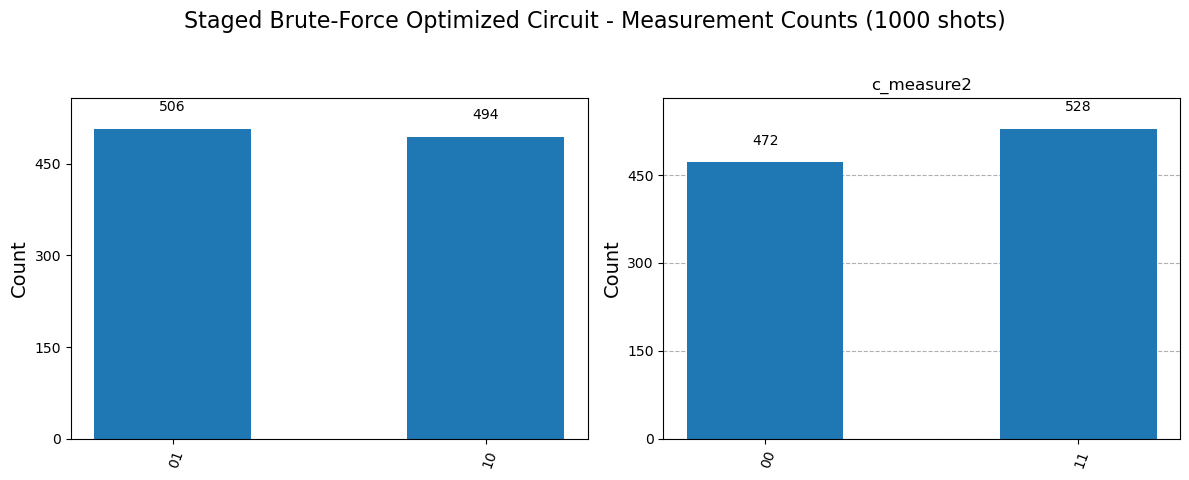

In [6]:
# --- Demonstrate Staged Brute-Force Search ---
print("\n" + "="*40)
print("--- Running Staged Brute-Force Search ---")
print("="*40)
max_staged_depth = 4
staged_nshots_config = [100, 500, 1000]
staged_discard_config = [0.25, 0.50] # Discard 25% after 100 shots, 50% of remaining after 500 shots

best_cnot_sequence_staged, min_kl_staged = find_best_cnot_sequence_brute_force_staged(
    circ_bell,
    circ_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    max_cnot_depth=max_staged_depth,
    nshots_stages=staged_nshots_config,
    discard_percentages=staged_discard_config
)

print("\n" + "="*40)
if best_cnot_sequence_staged:
    print(f"Staged Brute-Force Search Optimal CNOT sequence (Depth {max_staged_depth}) found:")
    for cnot in best_cnot_sequence_staged:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_staged:.6f}")

    # Construct and draw the final best circuit from staged brute-force search
    ng_circ1_for_staged = circ_bell.num_qubits
    base_combined_circuit_staged = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_staged = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_staged, ng_circ1_for_staged, best_cnot_sequence_staged
    )
    print("\n--- Final Optimized Circuit (Staged Brute-Force) ---")
    print(final_best_circuit_staged.draw('text'))

    # Plot histograms for the staged brute-force circuit
    plot_measurement_histograms(final_best_circuit_staged, nshots=1000, title_prefix="Staged Brute-Force Optimized Circuit")

else:
    print("Staged Brute-Force Search: No CNOT configuration sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_staged:.6f}")
    # Draw the baseline circuit
    base_combined_circuit_staged = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_staged = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_staged, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_staged.draw('text'))

    # Plot histograms for the baseline circuit
    plot_measurement_histograms(final_best_circuit_staged, nshots=1000, title_prefix="Baseline Circuit (Staged Brute-Force)")
print("="*40 + "\n")

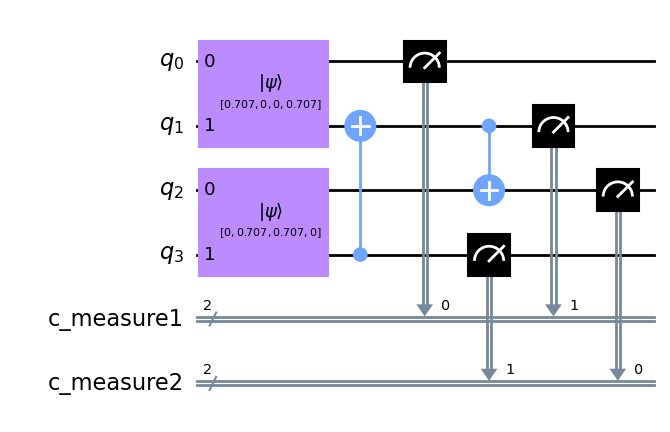

In [13]:
final_best_circuit_greedy.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)


--- Simulating and Plotting Histograms for: Greedy Optimized Circuit ---
Counts for c_measure1: {'01': 520, '00': 495, '10': 499, '11': 486}
Counts for c_measure2: {'10': 520, '01': 495, '11': 499, '00': 486}


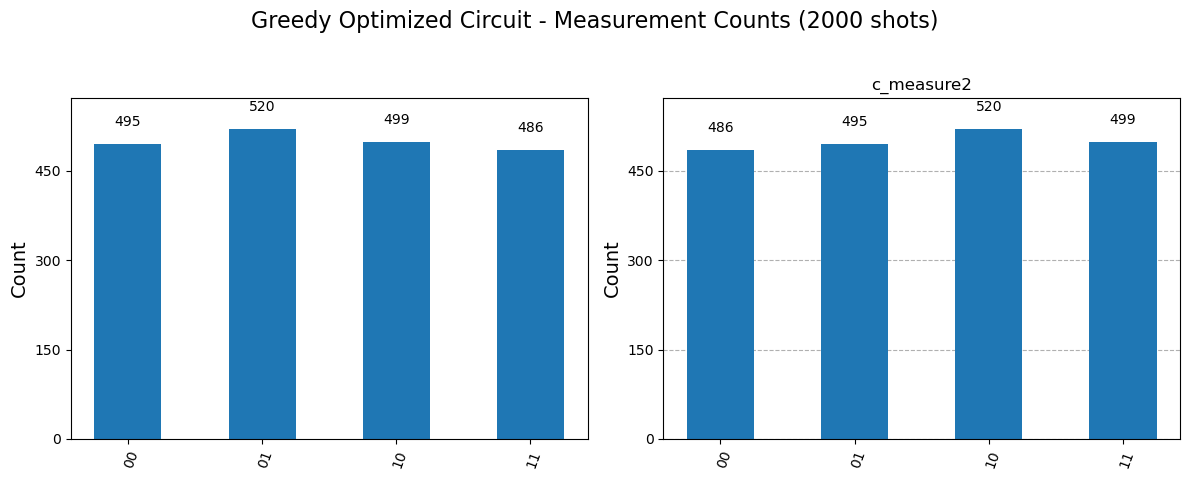

In [14]:
plot_measurement_histograms(final_best_circuit_greedy, nshots=2000, title_prefix="Greedy Optimized Circuit")

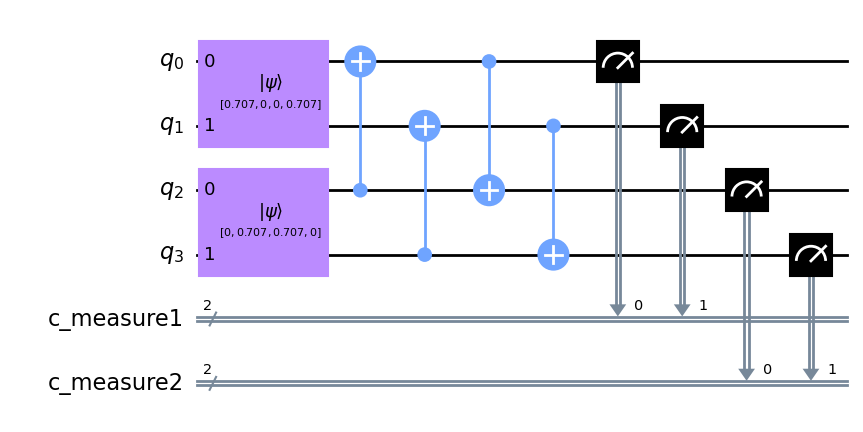

In [15]:
final_best_circuit_brute_force.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)


--- Simulating and Plotting Histograms for: Brute-Force Optimized Circuit ---
Counts for c_measure1: {'01': 510, '10': 490}
Counts for c_measure2: {'00': 509, '11': 491}


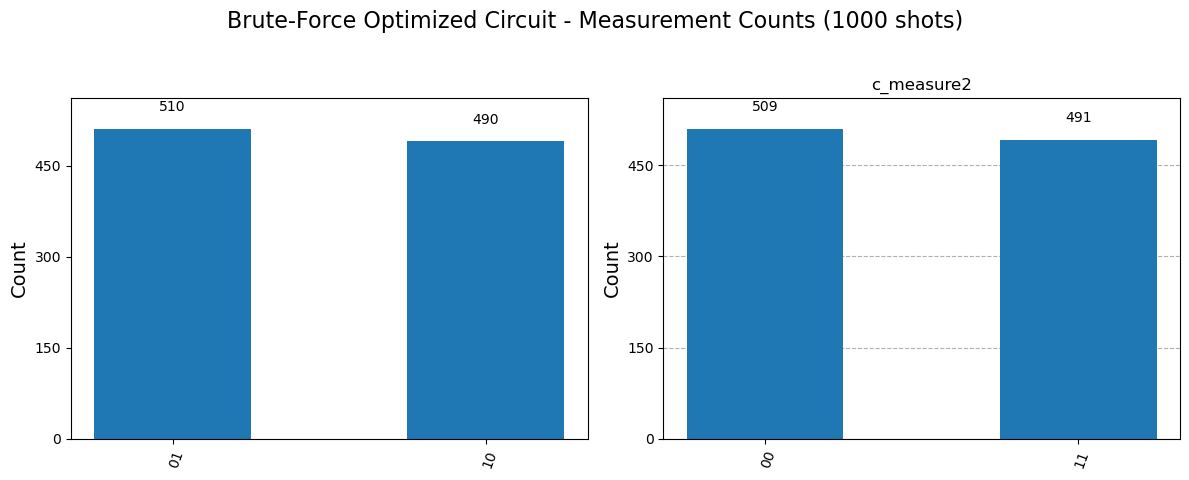

In [16]:
plot_measurement_histograms(final_best_circuit_brute_force, nshots=1000, title_prefix="Brute-Force Optimized Circuit")

In [11]:
# 1. Define initial circuits for concatenation
state_probs_bell = [1/np.sqrt(2), 0, 0, 1/np.sqrt(2)] # 2-qubit state
circ_bell = create_initial_circuit(state_vec_probs=state_probs_bell)

state_probs_ghz_ish = [0, 1/np.sqrt(2), 1/np.sqrt(2), 0] # 2-qubit state
circ_ghz_ish = create_initial_circuit(state_vec_probs=state_probs_ghz_ish)

# Define the target state vectors
state_probs_target1_amplitudes = np.array([0, 1/np.sqrt(2), 1/np.sqrt(2), 0])
state_probs_target2_amplitudes = np.array([1/np.sqrt(2), 0, 0, 1/np.sqrt(2)])


--- Running CRX Angle Optimization (based on Brute-Force CNOT topology) ---

--- Starting CRX Angle Optimization (4 CRX gates) ---

Optimization Results:
  Success: True
  Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  Optimized Angles: ['3.1416', '3.1416', '3.1416', '3.1416']
CRX Angle Optimization took: 13.93 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['3.1416', '3.1416', '3.1416', '3.1416']
  Minimum Combined KL Divergence with Optimized CRX: 0.000141


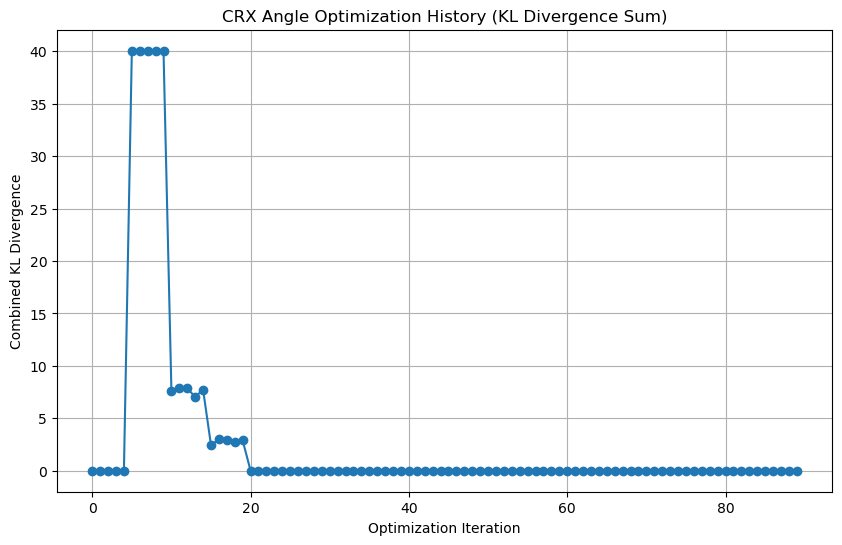


--- Final Optimized Circuit (CRX Angles) ---
              ┌──────────────────────────────────┐┌────────────┐              »
         q_0: ┤0                                 ├┤ Rx(3.1416) ├──────────────»
              │  Initialize(0.70711,0,0,0.70711) │└─────┬──────┘┌────────────┐»
         q_1: ┤1                                 ├──────┼───────┤ Rx(3.1416) ├»
              ├──────────────────────────────────┤      │       └─────┬──────┘»
         q_2: ┤0                                 ├──────■─────────────┼───────»
              │  Initialize(0,0.70711,0.70711,0) │                    │       »
         q_3: ┤1                                 ├────────────────────■───────»
              └──────────────────────────────────┘                            »
c_measure1: 2/════════════════════════════════════════════════════════════════»
                                                                              »
c_measure2: 2/════════════════════════════════════════════════════════════

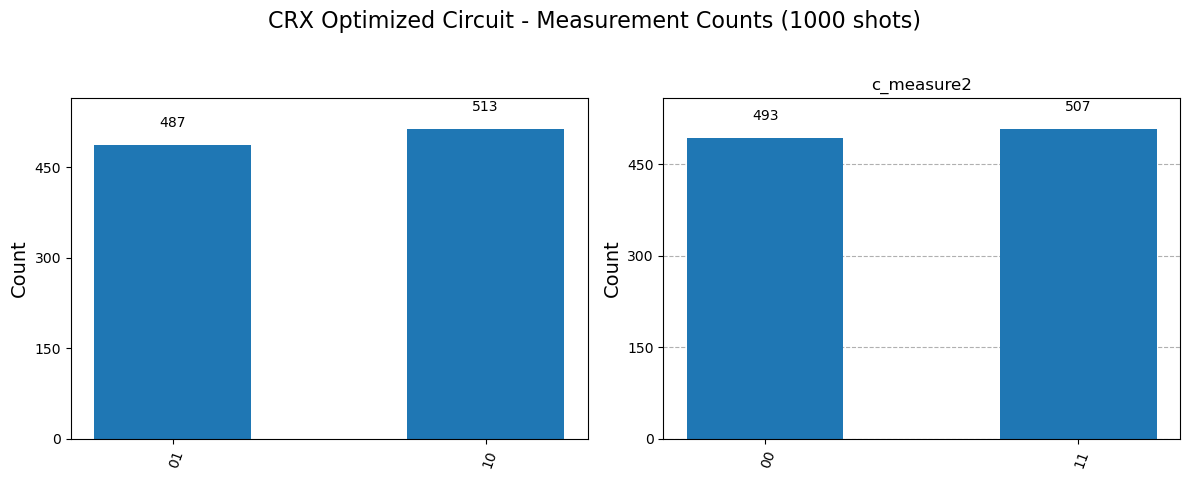

In [20]:
# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on Brute-Force CNOT topology) ---")
print("="*40)
optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ_bell,
    circ_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    best_cnot_sequence_brute_force, # Use the CNOT topology found by brute-force
    nshots=2000,
    opt_method='L-BFGS-B', # Using L-BFGS-B for angle optimization
    initial_angle_value=np.pi # Start angles at pi (CNOT equivalent)
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish),
    circ_bell.num_qubits,
    best_cnot_sequence_brute_force,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
plot_measurement_histograms(final_crx_optimized_circuit, nshots=1000, title_prefix="CRX Optimized Circuit")